Train samples: 60000, Test samples: 10000
Epoch 1/10 - loss: 0.5048 - accuracy: 0.8715 - val_loss: 0.3489 - val_accuracy: 0.9054
Epoch 2/10 - loss: 0.3476 - accuracy: 0.9034 - val_loss: 0.3147 - val_accuracy: 0.9118
Epoch 3/10 - loss: 0.3224 - accuracy: 0.9101 - val_loss: 0.3013 - val_accuracy: 0.9176
Epoch 4/10 - loss: 0.3090 - accuracy: 0.9135 - val_loss: 0.2927 - val_accuracy: 0.9181
Epoch 5/10 - loss: 0.3005 - accuracy: 0.9159 - val_loss: 0.2869 - val_accuracy: 0.9202
Epoch 6/10 - loss: 0.2943 - accuracy: 0.9185 - val_loss: 0.2836 - val_accuracy: 0.9185
Epoch 7/10 - loss: 0.2894 - accuracy: 0.9193 - val_loss: 0.2808 - val_accuracy: 0.9217
Epoch 8/10 - loss: 0.2858 - accuracy: 0.9202 - val_loss: 0.2787 - val_accuracy: 0.9221
Epoch 9/10 - loss: 0.2825 - accuracy: 0.9215 - val_loss: 0.2774 - val_accuracy: 0.9213
Epoch 10/10 - loss: 0.2798 - accuracy: 0.9218 - val_loss: 0.2766 - val_accuracy: 0.9229
dict_keys(['accuracy', 'val_accuracy', 'loss', 'val_loss'])


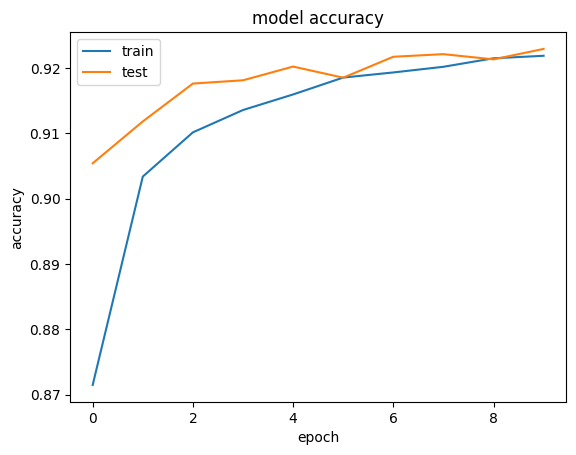

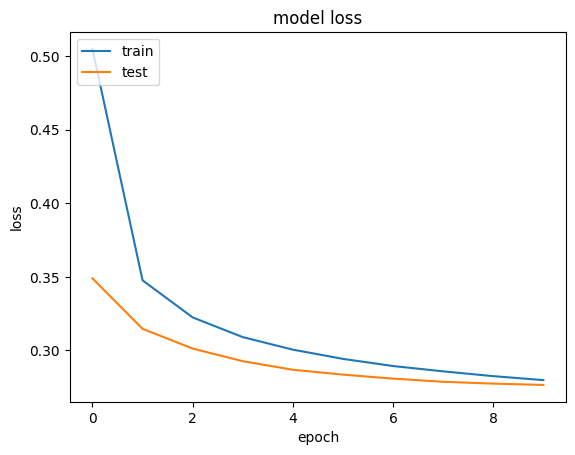

In [ ]:
# 1. SoftMax
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Load the real training and test dataset using torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] floats
    transforms.Lambda(lambda x: torch.flatten(x)) # Flatten to 1D array of 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

input_shape = 28 * 28
nb_classes = 10
batch_size = 80 #160

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# The Sequential model is a linear stack of layers
# Note: Softmax is omitted here because PyTorch's CrossEntropyLoss intrinsically applies LogSoftmax.
model = nn.Sequential(
    nn.Linear(input_shape, nb_classes)
)

# Before training a model, configure the learning process
# using the cross-entropy loss function (objective)
# PyTorch's CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss(),
# so we don't need an explicit Softmax layer in the model.
criterion = nn.CrossEntropyLoss()

# using the stochastic gradient descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 10 epochs is enough for the real MNIST dataset
epochs = 10

# Dictionary to store metrics
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# fit the model, the training process
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()           # clear the gradients
        outputs = model(inputs)         # forward pass
        loss = criterion(outputs, labels) # calculate loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        # Track accuracy and loss
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # Disable gradients during validation
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Save to history dict
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

# list all data in history
print(history.keys())

plt.figure(1)
# summarize history for accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=False)

plt.figure(2)
# summarize history for loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=True)


Train samples: 60000, Test samples: 10000
Epoch 1/10 - loss: 1.6074 - accuracy: 0.4569 - val_loss: 0.4778 - val_accuracy: 0.8573
Epoch 2/10 - loss: 0.3689 - accuracy: 0.8894 - val_loss: 0.2476 - val_accuracy: 0.9254
Epoch 3/10 - loss: 0.2074 - accuracy: 0.9389 - val_loss: 0.1592 - val_accuracy: 0.9533
Epoch 4/10 - loss: 0.1462 - accuracy: 0.9566 - val_loss: 0.1242 - val_accuracy: 0.9625
Epoch 5/10 - loss: 0.1140 - accuracy: 0.9666 - val_loss: 0.1136 - val_accuracy: 0.9669
Epoch 6/10 - loss: 0.0933 - accuracy: 0.9728 - val_loss: 0.1000 - val_accuracy: 0.9683
Epoch 7/10 - loss: 0.0779 - accuracy: 0.9763 - val_loss: 0.0956 - val_accuracy: 0.9702
Epoch 8/10 - loss: 0.0653 - accuracy: 0.9802 - val_loss: 0.0895 - val_accuracy: 0.9720
Epoch 9/10 - loss: 0.0560 - accuracy: 0.9825 - val_loss: 0.0905 - val_accuracy: 0.9726
Epoch 10/10 - loss: 0.0467 - accuracy: 0.9858 - val_loss: 0.0889 - val_accuracy: 0.9738
dict_keys(['accuracy', 'val_accuracy', 'loss', 'val_loss'])


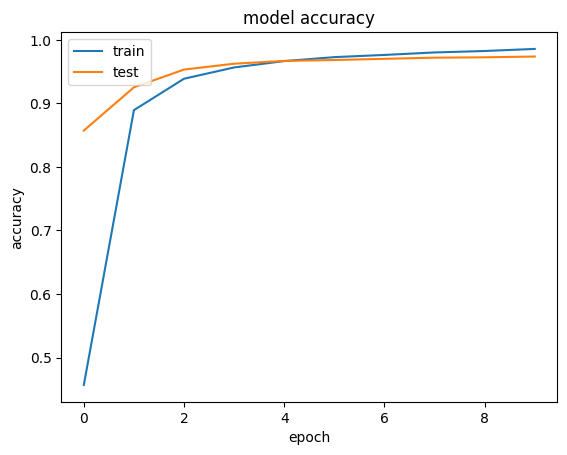

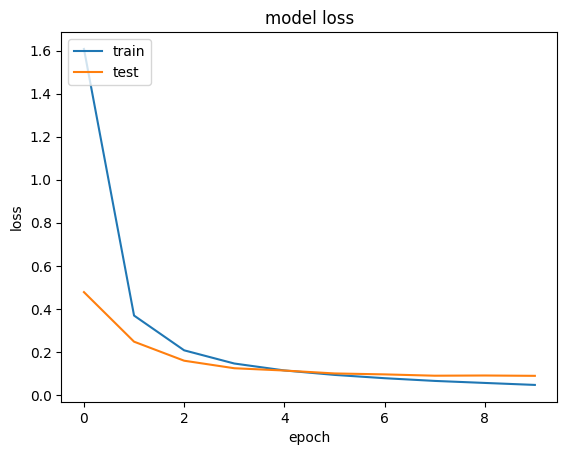

In [ ]:
# 2. Add more fully connected layers
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Load the real training and test dataset using torchvision
transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] floats
    transforms.Lambda(lambda x: torch.flatten(x)) # Flatten to 1D array of 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

input_shape = 28 * 28
nb_classes = 10
batch_size = 160

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# The Sequential model is a linear stack of layers
# Note: Softmax is omitted here because PyTorch's CrossEntropyLoss intrinsically applies LogSoftmax.
model = nn.Sequential(
    nn.Linear(input_shape, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 60),
    nn.ReLU(),
    nn.Linear(60, 30),
    nn.ReLU(),
    nn.Linear(30, nb_classes)
)

# Before training a model, configure the learning process
# using the cross-entropy loss function (objective)
# PyTorch's CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss(),
# so we don't need an explicit Softmax layer in the model.
criterion = nn.CrossEntropyLoss()

# using the stochastic gradient descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 10 epochs is enough for the real MNIST dataset
epochs = 10

# Dictionary to store metrics
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

# fit the model, the training process
for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()           # clear the gradients
        outputs = model(inputs)         # forward pass
        loss = criterion(outputs, labels) # calculate loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        # Track accuracy and loss
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): # Disable gradients during validation
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # Save to history dict
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

# list all data in history
print(history.keys())

plt.figure(1)
# summarize history for accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=False)

plt.figure(2)
# summarize history for loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show(block=True)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Training Data
x_train = np.random.uniform(-np.pi, np.pi, (100, 1)).astype(np.float32)
y_train = np.sin(x_train)

x_train_tensor = torch.from_numpy(x_train)
y_train_tensor = torch.from_numpy(y_train)

# 2. Define the Model
class SinApproximator(nn.Module):
    def __init__(self):
        super(SinApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SinApproximator()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

Epoch [200/1000], Loss: 0.015075
Epoch [400/1000], Loss: 0.006232
Epoch [600/1000], Loss: 0.000728
Epoch [800/1000], Loss: 0.000150
Epoch [1000/1000], Loss: 0.000065


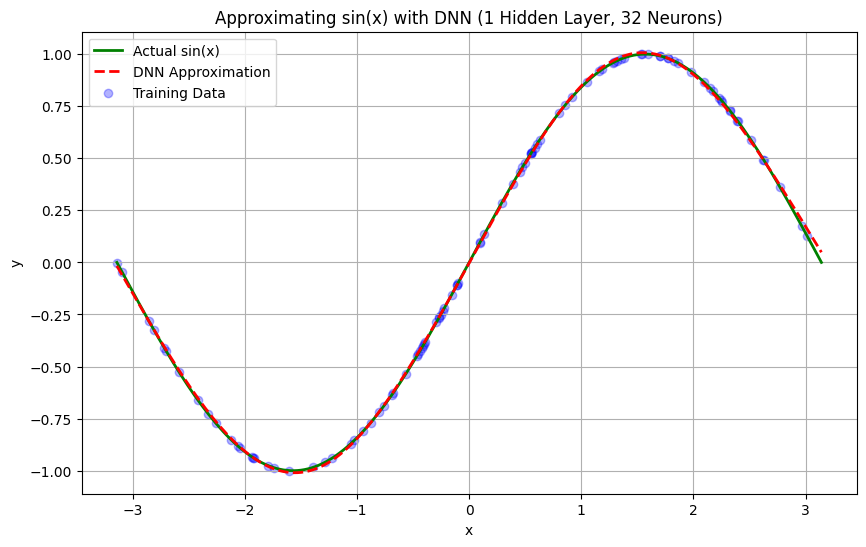

In [ ]:
# 4. Visualization
x_test = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1).astype(np.float32)
x_test_tensor = torch.from_numpy(x_test)

model.eval()
with torch.no_grad():
    y_pred = model(x_test_tensor).numpy()

plt.figure(figsize=(10, 6))
plt.plot(x_test, np.sin(x_test), 'g-', label='Actual sin(x)', linewidth=2)
plt.plot(x_test, y_pred, 'r--', label='DNN Approximation', linewidth=2)
plt.scatter(x_train, y_train, color='blue', alpha=0.3, label='Training Data')
plt.title('Approximating sin(x) with DNN (1 Hidden Layer, 32 Neurons)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda
Generated 500 training samples.
X_train shape: torch.Size([500, 2]), z_train shape: torch.Size([500, 1])
Epoch [200/2000], Loss: 0.0840
Epoch [400/2000], Loss: 0.0316
Epoch [600/2000], Loss: 0.0314
Epoch [800/2000], Loss: 0.0039
Epoch [1000/2000], Loss: 0.0068
Epoch [1200/2000], Loss: 0.0167
Epoch [1400/2000], Loss: 0.0022
Epoch [1600/2000], Loss: 0.0024
Epoch [1800/2000], Loss: 0.0043
Epoch [2000/2000], Loss: 0.0026
Training finished.


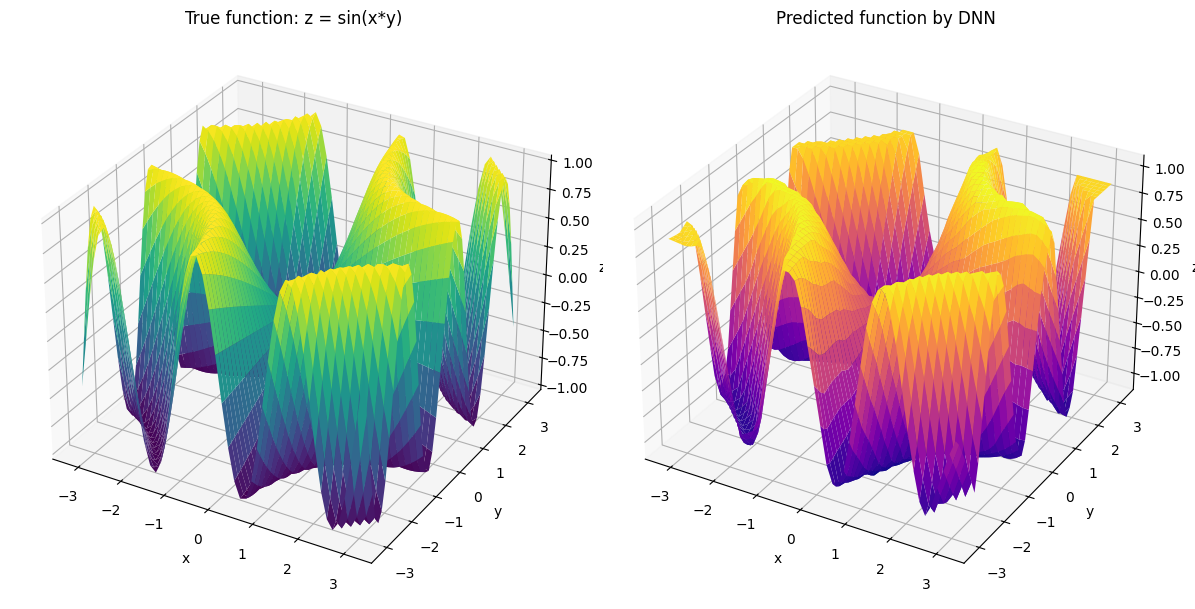

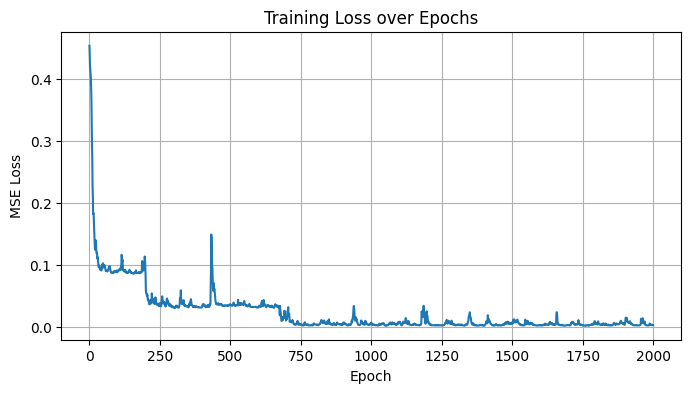

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Generate Training Data
num_samples = 500
low_bound = -np.pi
high_bound = np.pi

# Generate x and y values uniformly from [-pi, pi]
x_uniform = torch.rand(num_samples, 1) * (high_bound - low_bound) + low_bound
y_uniform = torch.rand(num_samples, 1) * (high_bound - low_bound) + low_bound

# Normalize to [-1, 1]
x_norm = x_uniform / high_bound
y_norm = y_uniform / high_bound

# Apply transformation to bias samples towards the edges/corners
power = 1.0
x_train = torch.sign(x_norm) * torch.pow(torch.abs(x_norm), power) * high_bound
y_train = torch.sign(y_norm) * torch.pow(torch.abs(y_norm), power) * high_bound

# Calculate z = sin(x*y)
z_train = torch.sin(x_train * y_train)

# Combine x and y into a single input tensor (features)
X_train = torch.cat((x_train, y_train), 1)

print(f"Generated {num_samples} training samples.")
print(f"X_train shape: {X_train.shape}, z_train shape: {z_train.shape}")

# Create DataLoader for mini-batch training
batch_size = 64
dataset = TensorDataset(X_train, z_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 2. Define the DNN Model
class SineApproximator(nn.Module):
    def __init__(self):
        super(SineApproximator, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(2, 150), # Input (x,y) -> 150 neurons
            nn.ReLU(),        # ReLU activation
            nn.Linear(150, 100), # 150 neurons -> 100 neurons
            nn.ReLU(),
            nn.Linear(100, 50), # 100 neurons -> 50 neurons
            nn.ReLU(),
            nn.Linear(50, 1)  # 50 neurons -> Output (z)
        )

    def forward(self, x):
        return self.layer(x)

# Move model to the selected device
model_sine = SineApproximator().to(device)

# 3. Define Loss Function and Optimizer
criterion_sine = nn.MSELoss() # Mean Squared Error for regression
optimizer_sine = optim.Adam(model_sine.parameters(), lr=0.01)

# 4. Train the Model
epochs_sine = 2000 # Reduced because mini-batch creates more updates per epoch

history_sine = {'loss': []}

for epoch in range(epochs_sine):
    model_sine.train()
    running_loss = 0.0

    for batch_x, batch_z in dataloader:
        # Move tensors to the configured device
        batch_x, batch_z = batch_x.to(device), batch_z.to(device)

        # Forward pass
        outputs = model_sine(batch_x)
        loss = criterion_sine(outputs, batch_z)

        # Backward and optimize
        optimizer_sine.zero_grad()
        loss.backward()
        optimizer_sine.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / num_samples
    history_sine['loss'].append(epoch_loss)

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs_sine}], Loss: {epoch_loss:.4f}')

print("Training finished.")

# 5. Evaluate and Visualize

# Generate test data grid for plotting
num_test_points = 50
lin_space = np.linspace(low_bound, high_bound, num_test_points)
X_grid, Y_grid = np.meshgrid(lin_space, lin_space)

# Convert grid to torch tensor and move to device
X_test_grid = torch.tensor(np.array([X_grid.flatten(), Y_grid.flatten()]).T, dtype=torch.float32).to(device)

# Predict z values using the trained model
model_sine.eval() # Set model to evaluation mode
with torch.no_grad():
    # Make sure to bring predictions back to the CPU for numpy/plotting
    Z_pred = model_sine(X_test_grid).cpu().numpy().reshape(num_test_points, num_test_points)

# Calculate actual z values
Z_true = np.sin(X_grid * Y_grid)

# Plotting
fig = plt.figure(figsize=(12, 6))

# Plot True function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, cmap='viridis')
ax1.set_title('True function: z = sin(x*y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Plot Predicted function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, cmap='plasma')
ax2.set_title('Predicted function by DNN')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

# Plot loss history
plt.figure(figsize=(8, 4))
plt.plot(history_sine['loss'])
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()